<a href="https://colab.research.google.com/github/drlukeweng/NCHU/blob/main/Week3_Lab2_Radiomics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Radiomics – From ROI to Clinical Prediction
## 智慧醫療中的醫學影像 | Week 3

**Learning Objectives:**
- Extract radiomics features from a synthetic tumor ROI
- Compute first-order statistics, shape features, and GLCM texture features
- Apply feature selection with LASSO regularization
- Build and evaluate a predictive model with cross-validation

**Estimated Time:** 90 minutes

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import ndimage
from scipy.stats import skew, kurtosis
from skimage.draw import disk, ellipse
from skimage import measure
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Lasso, LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')
print("✅ All libraries loaded")

✅ All libraries loaded


## Part 1: Synthetic Tumor ROI Dataset

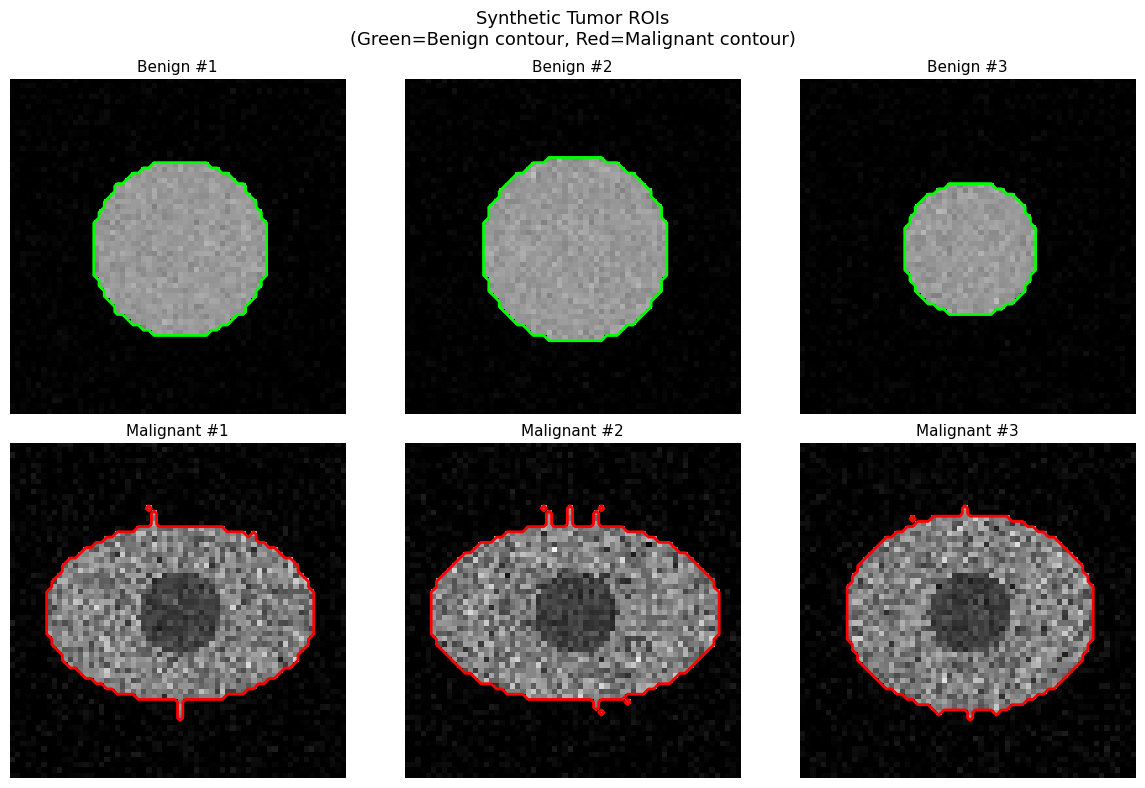

In [ ]:
def generate_tumor_roi(size=64, tumor_type='benign', seed=0):
    """
    Generate a synthetic tumor ROI.
    Benign: smooth, homogeneous, round
    Malignant: irregular, heterogeneous, lobulated
    """
    np.random.seed(seed)
    image = np.zeros((size, size))
    mask = np.zeros((size, size), dtype=bool)
    cx, cy = size//2, size//2

    if tumor_type == 'benign':
        # Smooth, round, homogeneous
        radius = size//4 + np.random.randint(-3, 4)
        rr, cc = disk((cy, cx), radius)
        valid = (rr >= 0) & (rr < size) & (cc >= 0) & (cc < size)
        image[rr[valid], cc[valid]] = 0.6 + np.random.normal(0, 0.03, valid.sum())
        mask[rr[valid], cc[valid]] = True
        image += np.random.normal(0, 0.02, image.shape)
    else:
        # Irregular, heterogeneous, spiculated
        rr, cc = ellipse(cy, cx, size//4 + np.random.randint(0, 6),
                         size//3 + np.random.randint(0, 8))
        valid = (rr >= 0) & (rr < size) & (cc >= 0) & (cc < size)
        image[rr[valid], cc[valid]] = 0.5 + np.random.normal(0, 0.12, valid.sum())
        mask[rr[valid], cc[valid]] = True
        # Add necrotic core (dark center)
        rr2, cc2 = disk((cy, cx), size//8)
        valid2 = (rr2 >= 0) & (rr2 < size) & (cc2 >= 0) & (cc2 < size)
        image[rr2[valid2], cc2[valid2]] = 0.25 + np.random.normal(0, 0.04, valid2.sum())
        # Add spicules
        for angle in np.random.choice(range(0, 360, 15), 8, replace=False):
            r = np.deg2rad(angle)
            for d in range(size//4, size//3):
                py = int(cy + d * np.sin(r))
                px = int(cx + d * np.cos(r))
                if 0 <= py < size and 0 <= px < size:
                    image[py, px] = 0.55 + np.random.normal(0, 0.05)
                    mask[py, px] = True
        image += np.random.normal(0, 0.04, image.shape)

    image = np.clip(image, 0, 1)
    return image, mask

# Visualize examples
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i in range(3):
    img, msk = generate_tumor_roi(tumor_type='benign', seed=i)
    axes[0, i].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[0, i].contour(msk, colors='lime', linewidths=2)
    axes[0, i].set_title(f'Benign #{i+1}', fontsize=11)
    axes[0, i].axis('off')

    img, msk = generate_tumor_roi(tumor_type='malignant', seed=i+10)
    axes[1, i].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[1, i].contour(msk, colors='red', linewidths=2)
    axes[1, i].set_title(f'Malignant #{i+1}', fontsize=11)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('BENIGN', fontsize=12, fontweight='bold', color='green')
axes[1, 0].set_ylabel('MALIGNANT', fontsize=12, fontweight='bold', color='red')
plt.suptitle('Synthetic Tumor ROIs\n(Green=Benign contour, Red=Malignant contour)', fontsize=13)
plt.tight_layout()
plt.show()

## Part 2: First-Order Features

In [ ]:
def extract_first_order_features(image, mask):
    """Extract first-order statistical features from ROI"""
    roi = image[mask]
    n = len(roi)

    mean = np.mean(roi)
    std = np.std(roi)
    features = {
        'fo_mean': mean,
        'fo_std': std,
        'fo_variance': np.var(roi),
        'fo_skewness': skew(roi),
        'fo_kurtosis': kurtosis(roi),
        'fo_entropy': -np.sum([(p * np.log2(p+1e-12))
                               for p in np.histogram(roi, bins=64, density=True)[0] / 64]),
        'fo_energy': np.sum(roi**2),
        'fo_mean_abs_dev': np.mean(np.abs(roi - mean)),
        'fo_p10': np.percentile(roi, 10),
        'fo_p25': np.percentile(roi, 25),
        'fo_median': np.median(roi),
        'fo_p75': np.percentile(roi, 75),
        'fo_p90': np.percentile(roi, 90),
        'fo_iqr': np.percentile(roi, 75) - np.percentile(roi, 25),
        'fo_range': roi.max() - roi.min(),
        'fo_uniformity': np.sum(np.histogram(roi, bins=64, density=True)[0]**2) / 64,
    }
    return features

# Test on one sample
img, msk = generate_tumor_roi(tumor_type='benign', seed=0)
features = extract_first_order_features(img, msk)
print("📊 First-Order Features (Benign tumor):")
for k, v in features.items():
    print(f"   {k:<25}: {v:.4f}")

📊 First-Order Features (Benign tumor):
   fo_mean                  : 0.5997
   fo_std                   : 0.0346
   fo_variance              : 0.0012
   fo_skewness              : -0.0831
   fo_kurtosis              : 0.1156
   fo_entropy               : 15.0051
   fo_energy                : 320.7348
   fo_mean_abs_dev          : 0.0272
   fo_p10                   : 0.5552
   fo_p25                   : 0.5776
   fo_median                : 0.6009
   fo_p75                   : 0.6227
   fo_p90                   : 0.6435
   fo_iqr                   : 0.0450
   fo_range                 : 0.2094
   fo_uniformity            : 40.8302


## Part 3: Shape Features

In [ ]:
def extract_shape_features(mask):
    """Extract 2D shape features from binary mask"""
    # Label connected components
    labeled = measure.label(mask)
    regions = measure.regionprops(labeled)
    if not regions:
        return {}

    region = max(regions, key=lambda r: r.area)

    area = region.area
    perimeter = region.perimeter

    # Circularity (sphericity in 2D)
    circularity = (4 * np.pi * area) / (perimeter**2 + 1e-8)

    # Elongation: minor/major axis ratio
    if region.major_axis_length > 0:
        elongation = region.minor_axis_length / region.major_axis_length
    else:
        elongation = 1.0

    features = {
        'shape_area': area,
        'shape_perimeter': perimeter,
        'shape_circularity': circularity,
        'shape_elongation': elongation,
        'shape_solidity': region.solidity,
        'shape_extent': region.extent,
        'shape_euler_number': region.euler_number,
        'shape_major_axis': region.major_axis_length,
        'shape_minor_axis': region.minor_axis_length,
        'shape_eccentricity': region.eccentricity,
    }
    return features

print("📐 Shape Features (Benign vs Malignant):")
print(f"{'Feature':<25} {'Benign':>10} {'Malignant':>12}")
print("-" * 50)
ben_img, ben_msk = generate_tumor_roi(tumor_type='benign', seed=0)
mal_img, mal_msk = generate_tumor_roi(tumor_type='malignant', seed=10)
ben_shape = extract_shape_features(ben_msk)
mal_shape = extract_shape_features(mal_msk)
for k in ben_shape:
    print(f"{k:<25}: {ben_shape[k]:>10.4f} | {mal_shape.get(k, 0):>10.4f}")

📐 Shape Features (Benign vs Malignant):
Feature                       Benign    Malignant
--------------------------------------------------
shape_area               :   889.0000 |  1384.0000
shape_perimeter          :   109.2548 |   147.0183
shape_circularity        :     0.9359 |     0.8046
shape_elongation         :     1.0000 |     0.6598
shape_solidity           :     0.9737 |     0.9227
shape_extent             :     0.8163 |     0.6619
shape_euler_number       :     1.0000 |     1.0000
shape_major_axis         :    33.6429 |    51.7479
shape_minor_axis         :    33.6429 |    34.1429
shape_eccentricity       :     0.0000 |     0.7514


## Part 4: GLCM Texture Features

In [ ]:
from skimage.feature import graycomatrix, graycoprops

def extract_glcm_features(image, mask, levels=32):
    """Extract GLCM texture features"""
    roi = image.copy()
    roi[~mask] = 0
    # Crop to bounding box
    rprops = measure.regionprops(mask.astype(int))
    if not rprops: return {}
    minr, minc, maxr, maxc = rprops[0].bbox
    roi_crop = roi[minr:maxr, minc:maxc].astype(float)
    roi_disc = np.floor(roi_crop * (levels-1)).astype(np.uint8).clip(0, levels-1)

    glcm = graycomatrix(roi_disc, distances=[1,2], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=levels, symmetric=True, normed=True)

    features = {}
    for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']:
        vals = graycoprops(glcm, prop)
        features[f'glcm_{prop}_mean'] = vals.mean()
        features[f'glcm_{prop}_range'] = vals.max() - vals.min()
    return features

ben_glcm = extract_glcm_features(ben_img, ben_msk)
print("\n🔲 GLCM Features (Benign):")
for k, v in ben_glcm.items():
    print(f"   {k:<35}: {v:.4f}")


🔲 GLCM Features (Benign):
   glcm_contrast_mean                 : 20.1580
   glcm_contrast_range                : 12.0580
   glcm_dissimilarity_mean            : 1.9809
   glcm_dissimilarity_range           : 0.6997
   glcm_homogeneity_mean              : 0.5545
   glcm_homogeneity_range             : 0.0565
   glcm_energy_mean                   : 0.2514
   glcm_energy_range                  : 0.0209
   glcm_correlation_mean              : 0.7726
   glcm_correlation_range             : 0.1462
   glcm_ASM_mean                      : 0.0633
   glcm_ASM_range                     : 0.0106


## Part 5: Build Full Feature Dataset

In [ ]:
def extract_all_features(image, mask):
    features = {}
    features.update(extract_first_order_features(image, mask))
    features.update(extract_shape_features(mask))
    features.update(extract_glcm_features(image, mask))
    return features

# Generate dataset: 100 benign + 100 malignant
print("📦 Generating radiomics dataset...")
all_features = []
all_labels = []

for i in range(100):
    img, msk = generate_tumor_roi(tumor_type='benign', seed=i) # Fix: specify tumor_type
    feats = extract_all_features(img, msk)
    all_features.append(feats)
    all_labels.append(0)

for i in range(100):
    img, msk = generate_tumor_roi(tumor_type='malignant', seed=i+100) # Fix: specify tumor_type
    feats = extract_all_features(img, msk)
    all_features.append(feats)
    all_labels.append(1)

df = pd.DataFrame(all_features)
labels = np.array(all_labels)

print(f"✅ Dataset: {df.shape[0]} samples × {df.shape[1]} features")
print(f"   Class distribution: {(labels==0).sum()} benign, {(labels==1).sum()} malignant")
print(f"\nFeature groups:")
fo_cols = [c for c in df.columns if c.startswith('fo_')]
shape_cols = [c for c in df.columns if c.startswith('shape_')]
glcm_cols = [c for c in df.columns if c.startswith('glcm_')]
print(f"   First-order: {len(fo_cols)} features")
print(f"   Shape:       {len(shape_cols)} features")
print(f"   GLCM:        {len(glcm_cols)} features")
print("\nDataset Statistics:")
print(df.describe().round(3))

📦 Generating radiomics dataset...
✅ Dataset: 200 samples × 38 features
   Class distribution: 100 benign, 100 malignant

Feature groups:
   First-order: 16 features
   Shape:       10 features
   GLCM:        12 features

Dataset Statistics:
       fo_mean   fo_std  fo_variance  fo_skewness  fo_kurtosis  fo_entropy  \
count  200.000  200.000      200.000      200.000      200.000     200.000   
mean     0.533    0.091        0.011       -0.062       -0.244      10.115   
std      0.067    0.055        0.010        0.088        0.270       3.950   
min      0.453    0.033        0.001       -0.276       -0.688       5.589   
25%      0.467    0.036        0.001       -0.122       -0.478       6.193   
50%      0.538    0.089        0.010       -0.070       -0.290       9.272   
75%      0.600    0.146        0.021       -0.016       -0.029      13.890   
max      0.603    0.153        0.024        0.249        0.659      16.684   

       fo_energy  fo_mean_abs_dev   fo_p10   fo_p25  ..

## Part 6: Feature Selection with LASSO

🔍 Feature Selection with LASSO...
   Optimal lambda: 0.0005
   Features before: 38
   Features after LASSO: 11

   Selected features:
   1. fo_mean                            : coef=-0.0674
   2. fo_std                             : coef=0.3060
   3. fo_skewness                        : coef=-0.0017
   4. fo_entropy                         : coef=-0.0034
   5. fo_p10                             : coef=-0.0476
   6. fo_p75                             : coef=-0.0233
   7. shape_area                         : coef=0.0084
   8. shape_major_axis                   : coef=0.0185
   9. shape_eccentricity                 : coef=0.0051
   10. glcm_homogeneity_mean              : coef=-0.0064
   11. glcm_correlation_mean              : coef=-0.0188


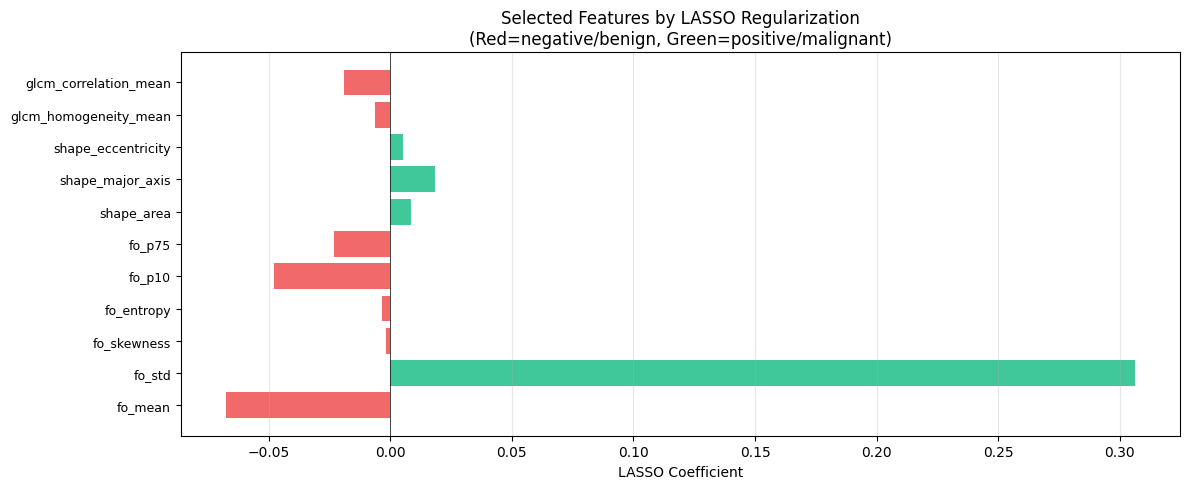

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

# Handle NaN/Inf
df = df.replace([np.inf, -np.inf], np.nan).fillna(df.median())
X = df.values
y = labels

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# LASSO feature selection
print("🔍 Feature Selection with LASSO...")
lasso_cv = LassoCV(cv=5, max_iter=5000, random_state=42)
lasso_cv.fit(X_scaled, y)
selected_mask = lasso_cv.coef_ != 0
selected_features = df.columns[selected_mask].tolist()

print(f"   Optimal lambda: {lasso_cv.alpha_:.4f}")
print(f"   Features before: {X.shape[1]}")
print(f"   Features after LASSO: {selected_mask.sum()}")
print(f"\n   Selected features:")
for i, (feat, coef) in enumerate(zip(df.columns[selected_mask], lasso_cv.coef_[selected_mask])):
    print(f"   {i+1}. {feat:<35}: coef={coef:.4f}")

# Visualize coefficients
nonzero_idx = np.where(selected_mask)[0]
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#EF4444' if c < 0 else '#10B981' for c in lasso_cv.coef_[selected_mask]]
ax.barh(range(len(nonzero_idx)), lasso_cv.coef_[selected_mask], color=colors, alpha=0.8)
ax.set_yticks(range(len(nonzero_idx)))
ax.set_yticklabels([df.columns[i] for i in nonzero_idx], fontsize=9)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('LASSO Coefficient')
ax.set_title('Selected Features by LASSO Regularization\n(Red=negative/benign, Green=positive/malignant)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Part 7: Model Building and Cross-Validation

📊 5-Fold Cross-Validation Results:
Model                           AUC (mean±std)
--------------------------------------------------
Logistic Regression      : AUC = 1.0000 ± 0.0000
Random Forest            : AUC = 1.0000 ± 0.0000


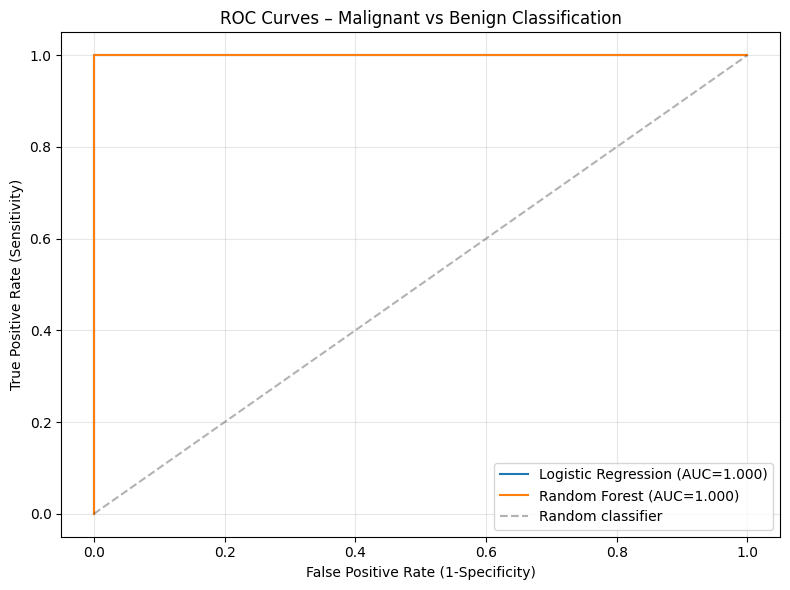

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve

X_selected = X_scaled[:, selected_mask]

models = {
    'Logistic Regression': LogisticRegression(C=1.0, random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("📊 5-Fold Cross-Validation Results:")
print(f"{'Model':<25} {'AUC (mean±std)':>20}")
print("-" * 50)

fig, ax = plt.subplots(figsize=(8, 6))
all_results = {}

for name, model in models.items():
    aucs = cross_val_score(model, X_selected, y, cv=skf, scoring='roc_auc')
    all_results[name] = aucs
    print(f"{name:<25}: AUC = {aucs.mean():.4f} ± {aucs.std():.4f}")

    # Plot ROC for full dataset
    model.fit(X_selected, y)
    probs = model.predict_proba(X_selected)[:, 1]
    fpr, tpr, _ = roc_curve(y, probs)
    auc_full = roc_auc_score(y, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_full:.3f})')

ax.plot([0,1], [0,1], 'k--', alpha=0.3, label='Random classifier')
ax.set_xlabel('False Positive Rate (1-Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves – Malignant vs Benign Classification')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part 8: Reproducibility Analysis

In [ ]:
# Reproducibility analysis: add slight noise and see how features change
print("🔬 Reproducibility Analysis (adding σ=0.02 noise to images)...")
original_features = []
noisy_features = []

for i in range(50):
    img, msk = generate_tumor_roi(tumor_type='benign', seed=i)
    orig_feats = extract_all_features(img, msk)
    noisy_img = np.clip(img + np.random.normal(0, 0.02, img.shape), 0, 1)
    noisy_feats = extract_all_features(noisy_img, msk)
    original_features.append(orig_feats)
    noisy_features.append(noisy_feats)

df_orig = pd.DataFrame(original_features)
df_noisy = pd.DataFrame(noisy_features)

# Compute feature % change
pct_changes = (abs(df_noisy - df_orig) / (abs(df_orig) + 1e-8)).mean() * 100
print(f"\nTop 5 MOST robust features (smallest % change):")
print(pct_changes.nsmallest(5).round(2).to_string())
print(f"\nTop 5 LEAST robust features (largest % change):")
print(pct_changes.nlargest(5).round(2).to_string())
print(f"\nMedian feature % change: {pct_changes.median():.1f}%")
print("\n⚠️ Features with >10% change under small noise should be excluded from radiomics!")

🔬 Reproducibility Analysis (adding σ=0.02 noise to images)...

Top 5 MOST robust features (smallest % change):
shape_area           0.0
shape_perimeter      0.0
shape_circularity    0.0
shape_elongation     0.0
shape_solidity       0.0

Top 5 LEAST robust features (largest % change):
fo_skewness               185.69
fo_kurtosis               179.46
fo_variance                30.81
fo_uniformity              23.16
glcm_homogeneity_range     22.54

Median feature % change: 1.5%

⚠️ Features with >10% change under small noise should be excluded from radiomics!


## Exercises

**Exercise 1:** Add 10 more first-order features (e.g., coefficient of variation, robust mean absolute deviation). Does model AUC improve?

**Exercise 2:** Apply ICC-based filtering: simulate test-retest by adding noise (σ=0.01) to images and recompute features. Filter features with ICC < 0.75.

**Exercise 3:** Try ElasticNet (L1+L2) instead of pure LASSO. Compare the number of selected features.

**Exercise 4:** What happens if you include shape features in a shape-invariant task? Design an experiment to test feature importance.

**Exercise 5 (Critical Thinking):** With n=200 (100 benign, 100 malignant) and ~35 extracted features, what is the expected optimism bias in internal cross-validation? How would you correct for it?